# 14. Poster methodology figures

Poster-ready figures for the **methodology / data-wrangling** section of the
NeuroMonster A0 poster. The bulk of the project (notebooks 00–12) turned an
*unanalysable* CosMx dataset, where vendor segmentation discards ~44 % of
transcripts, into an analysable point pattern. This notebook banks that work
as a suite of individually polished 300-dpi panels, reusing the helper
functions from `00_functions.ipynb` and the canonical cleaned parquet.

Figures:
- **M1** segmentation dropout (grounds the work)
- **M2** GMM strip assignment
- **M3** adaptive-DBSCAN noise QC
- **M4** observation-window iterations (rect → convex → concave)
- **M5** multi-scale r-value design + edge correction
- **T**  tool-positioning map (where STIPPLE sits in the landscape)

All stats are read live from the data so the figures cannot drift.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

%run 00_functions.ipynb

REPO = Path("..") if Path("../results").is_dir() else Path(".")
FIGS = REPO / "results" / "figures"
FIGS.mkdir(parents=True, exist_ok=True)

df = pd.read_parquet(REPO / "data" / "processed" / "s1_all_strips_cleaned.parquet")
clean = ~df["is_noise"] & ~df["is_small_cluster"] & ~df["manually_excluded"]

# Shared poster palette (IBM accessible; strip colours match Figs C–H)
STRIP_COL = {"strip_1": "#785EF0", "strip_2": "#DC267F", "strip_3": "#FFB000"}
STRIP_LABELS = {"strip_1": "Strip 1 (control)",
                "strip_2": "Strip 2 (infected)",
                "strip_3": "Strip 3 (control)"}
C_KEEP, C_NOISE, C_SMALL = "#648FFF", "#DC267F", "#FE6100"
C_RECT, C_CONVEX, C_CONCAVE = "#648FFF", "#FE6100", "#1A9850"
GREY = "#BDBDBD"

# Pin Arial for a clean, consistent look across every figure (matches the poster
# body font). Arial is installed on this machine; fall back to DejaVu Sans if not.
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "DejaVu Sans"],
    "font.size": 11, "axes.titlesize": 13, "axes.titleweight": "bold",
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.dpi": 110, "savefig.dpi": 300,
})

n_total = len(df)
print(f"transcripts:        {n_total:,}")
print(f"unassigned (id=0):  {(df['cell_ID']==0).sum():,} ({100*(df['cell_ID']==0).mean():.1f}%)")
print(f"retained after QC:  {clean.sum():,} ({100*clean.mean():.1f}%)")
print(f"  noise {100*df['is_noise'].mean():.1f}%  small {100*df['is_small_cluster'].mean():.1f}%  manual {100*df['manually_excluded'].mean():.1f}%")
print(f"eps_used range:     [{df['eps_used'].min():.0f}, {df['eps_used'].max():.0f}] px")

transcripts:        702,873
unassigned (id=0):  306,340 (43.6%)
retained after QC:  611,150 (87.0%)
  noise 7.6%  small 2.0%  manual 5.4%
eps_used range:     [20, 30] px


## M0: The raw data: what survives vendor segmentation

One field of view, three layers from the CosMx `zarr`: the morphology image, the
vendor cell-segmentation mask (the layer we **discard**), and the raw transcripts
(the layer STIPPLE **carries through**). ~40% of transcripts fall in no cell.

saved 14_M0_raw_data.png | unassigned 0.405 | n_cells 148


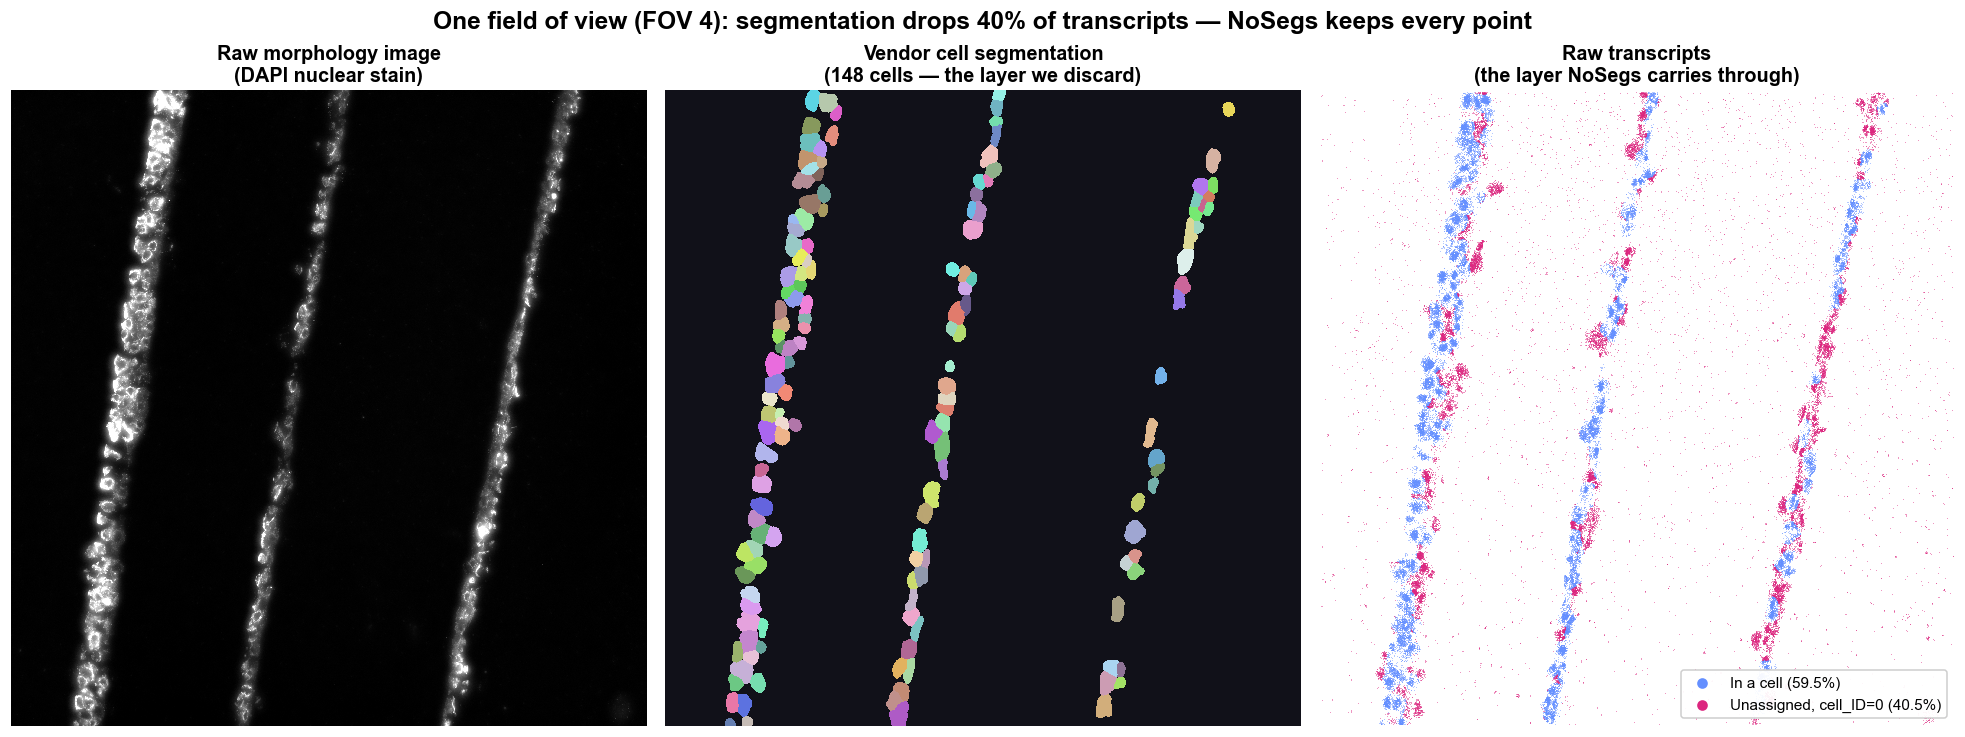

In [2]:
import warnings, logging
warnings.filterwarnings("ignore"); logging.disable(logging.CRITICAL)
import spatialdata as sd

C_ASSIGNED, C_UNASSIGNED = "#648FFF", "#DC267F"
FOV = 4

sdata = sd.read_zarr(str(REPO / "data" / "raw" / "Varsha_1234.zarr"))
img = np.asarray(sdata.images[f"{FOV}_image"][0])     # DAPI channel
lab = np.asarray(sdata.labels[f"{FOV}_labels"])       # vendor segmentation mask
pts = sdata.points[f"{FOV}_points"].compute()
H, W = lab.shape
unassigned = pts["cell_ID"] == 0
frac_un = unassigned.mean()
n_cells = int(lab.max())

# DAPI contrast stretch
lo, hi = np.percentile(img, [1, 99.5])
disp = np.clip((img - lo) / (hi - lo + 1e-9), 0, 1)

# random LUT for the segmentation labels (0 = background -> near-black)
rng = np.random.default_rng(0)
lut = rng.random((n_cells + 1, 3)) * 0.6 + 0.35
lut[0] = (0.07, 0.07, 0.10)
seg_rgb = lut[np.clip(lab, 0, n_cells)]

fig, ax = plt.subplots(1, 3, figsize=(18, 6.6))
ax[0].imshow(disp, cmap="gray", interpolation="nearest")
ax[0].set_title("Raw morphology image\n(DAPI nuclear stain)")
ax[1].imshow(seg_rgb, interpolation="nearest")
ax[1].set_title(f"Vendor cell segmentation\n({n_cells} cells - the layer we discard)")
ax[2].scatter(pts.loc[~unassigned, "x"], pts.loc[~unassigned, "y"], s=0.6,
              c=C_ASSIGNED, marker=".", linewidths=0, rasterized=True,
              label=f"In a cell ({(~unassigned).mean()*100:.1f}%)")
ax[2].scatter(pts.loc[unassigned, "x"], pts.loc[unassigned, "y"], s=0.6,
              c=C_UNASSIGNED, marker=".", linewidths=0, rasterized=True,
              label=f"Unassigned, cell_ID=0 ({frac_un*100:.1f}%)")
ax[2].set_xlim(0, W); ax[2].set_ylim(0, H); ax[2].invert_yaxis()
ax[2].set_aspect("equal"); ax[2].set_facecolor("white")
ax[2].set_title("Raw transcripts\n(the layer STIPPLE carries through)")
ax[2].legend(loc="lower right", fontsize=10, markerscale=18, framealpha=0.95)
for a in ax:
    a.set_xticks([]); a.set_yticks([])
    for s in a.spines.values():
        s.set_visible(False)
fig.suptitle(f"One field of view (FOV {FOV}): segmentation drops {frac_un*100:.0f}% "
             f"of transcripts - STIPPLE keeps every point",
             fontsize=16, fontweight="bold", y=1.02)
fig.tight_layout()
fig.savefig(FIGS / "14_M0_raw_data.png", dpi=300, bbox_inches="tight")
print("saved 14_M0_raw_data.png | unassigned", round(frac_un, 3), "| n_cells", n_cells)
plt.show()


## M1: Vendor segmentation dropout (grounds the work)

The motivating problem: NanoString's vendor segmentation never assigns ~44 %
of transcripts to a cell (`cell_ID = 0`), and the dropout is consistent across
every FOV, so it is not a local artefact. Any segmentation-dependent tool
(CellChat, LIANA, Bento) silently discards this signal.

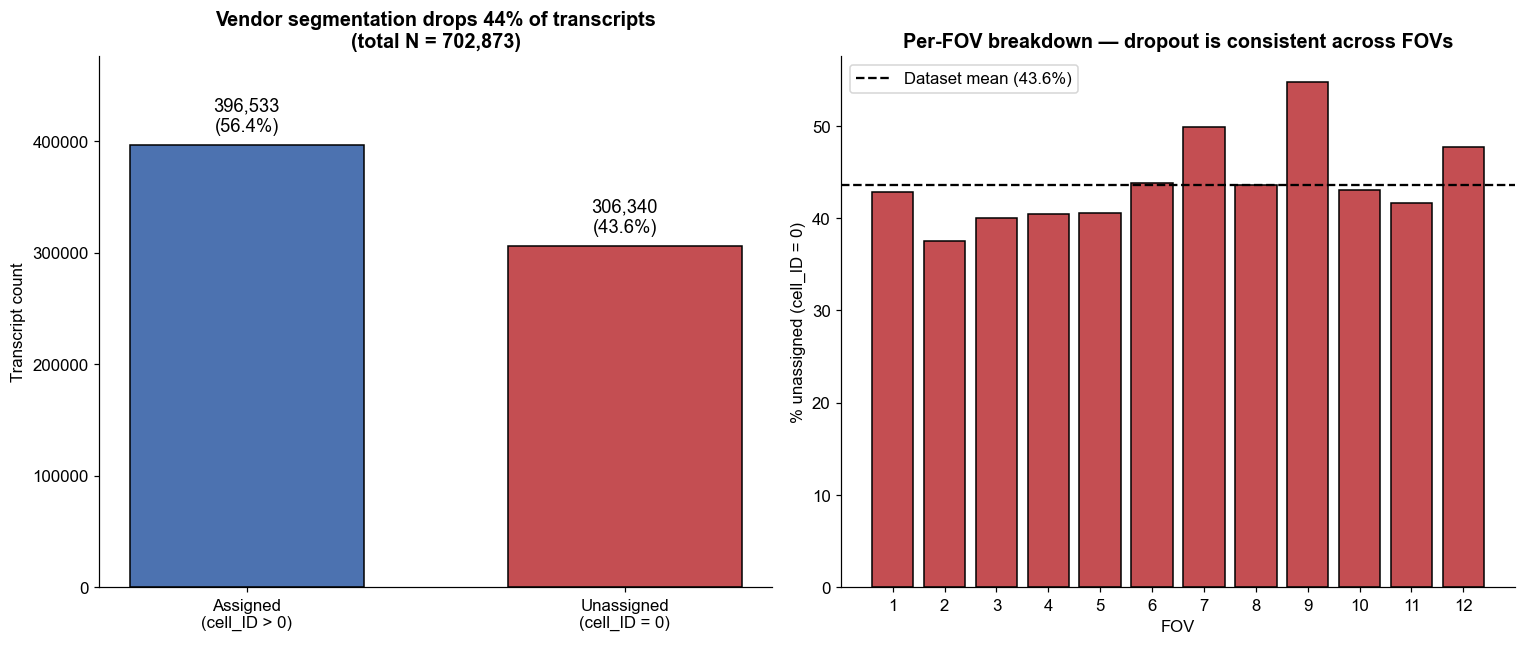

In [3]:
n_un = int((df["cell_ID"] == 0).sum())
n_as = n_total - n_un
pct_un = 100 * n_un / n_total

fig, (axL, axR) = plt.subplots(1, 2, figsize=(14, 6))

# Left - assigned vs unassigned
bars = axL.bar(["Assigned\n(cell_ID > 0)", "Unassigned\n(cell_ID = 0)"],
               [n_as, n_un], color=["#4C72B0", "#C44E52"],
               edgecolor="black", width=0.62)
for x, v in zip([0, 1], [n_as, n_un]):
    axL.text(x, v + n_total * 0.012, f"{v:,}\n({100*v/n_total:.1f}%)",
             ha="center", va="bottom", fontsize=12)
axL.set_ylabel("Transcript count")
axL.set_ylim(0, n_as * 1.20)
axL.set_title(f"Vendor segmentation drops {pct_un:.0f}% of transcripts\n(total N = {n_total:,})")

# Right - per-FOV consistency
per_fov = df.groupby("fov").apply(lambda g: 100 * (g["cell_ID"] == 0).mean())
axR.bar(per_fov.index.astype(str), per_fov.values, color="#C44E52", edgecolor="black")
axR.axhline(pct_un, ls="--", c="black", lw=1.5, label=f"Dataset mean ({pct_un:.1f}%)")
axR.set_xlabel("FOV")
axR.set_ylabel("% unassigned (cell_ID = 0)")
axR.set_title("Per-FOV breakdown - dropout is consistent across FOVs")
axR.legend()

fig.tight_layout()
fig.savefig(FIGS / "14_M1_segmentation_dropout.png", dpi=300, bbox_inches="tight")
plt.show()

## M2: GMM strip assignment

After PCA aligns the tissue axis (`x_rot_px`), a per-FOV 3-component Gaussian
mixture on the rotated x-coordinate separates the three tissue strips
(control / infected / control). Left: the final assignment across all FOVs -
three clean vertical bands. Right: the rotated-x histograms for three
representative FOVs, trimodal, with the fitted component-midpoint boundaries.

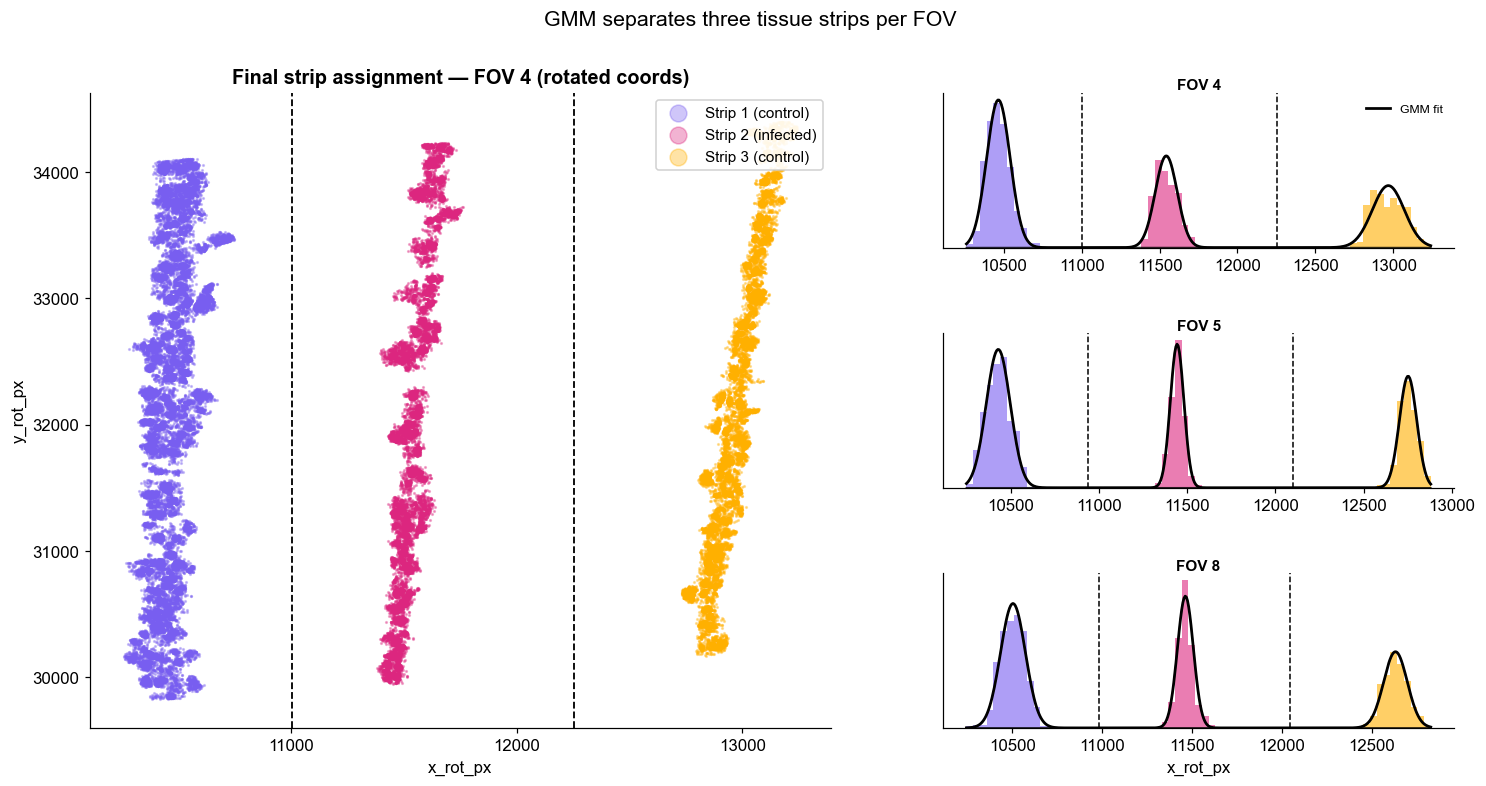

In [4]:
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import MaxNLocator
from sklearn.mixture import GaussianMixture
from scipy.stats import norm

fig = plt.figure(figsize=(16, 7.5))
gs = GridSpec(3, 2, width_ratios=[1.45, 1], hspace=0.55, wspace=0.18, figure=fig)

# Left - representative FOV rotated scatter (strips separate cleanly within a FOV;
# across-FOV the rotated-x ranges overlap, so we show one FOV for legibility)
LEFT_FOV = 4
axS = fig.add_subplot(gs[:, 0])
gL = df[(df["fov"] == LEFT_FOV) & clean]
for s, c in STRIP_COL.items():
    d = gL[gL["strip"] == s]
    axS.scatter(d["x_rot_px"], d["y_rot_px"], s=1.2, alpha=0.35, c=c,
                rasterized=True, label=STRIP_LABELS[s])
presentL = [s for s in ["strip_1", "strip_2", "strip_3"] if (gL["strip"] == s).any()]
mL = sorted(gL.groupby("strip")["x_rot_px"].mean().loc[presentL].values)
for b in [(mL[i] + mL[i + 1]) / 2 for i in range(len(mL) - 1)]:
    axS.axvline(b, color="black", ls="--", lw=1.2)
axS.xaxis.set_major_locator(MaxNLocator(4))
axS.set_xlabel("x_rot_px"); axS.set_ylabel("y_rot_px")
axS.set_title(f"Final strip assignment - FOV {LEFT_FOV} (rotated coords)")
axS.legend(markerscale=10, fontsize=10, loc="upper right", framealpha=0.9)

# Right - per-FOV rotated-x histograms with the fitted GMM curves overlaid.
# Each strip histogram is weighted to the *whole-FOV* density (1 / N_fov), so the
# stacked bars integrate to 1 and line up with the mixture pdf drawn on top.
rep_fovs = [4, 5, 8]
for k, fv in enumerate(rep_fovs):
    ax = fig.add_subplot(gs[k, 1])
    g = df[(df["fov"] == fv) & clean]
    x = g["x_rot_px"].to_numpy().reshape(-1, 1)
    n_fov = len(x)
    present = [s for s in ["strip_1", "strip_2", "strip_3"] if (g["strip"] == s).any()]
    bins = np.linspace(x.min(), x.max(), 70)
    bw = bins[1] - bins[0]
    for s in present:
        vals = g[g["strip"] == s]["x_rot_px"].to_numpy()
        ax.hist(vals, bins=bins, color=STRIP_COL[s], alpha=0.6,
                weights=np.full(len(vals), 1.0 / (n_fov * bw)))
    # Fit the n-component Gaussian mixture; overlay each component pdf + the total
    gm = GaussianMixture(n_components=len(present), random_state=0).fit(x)
    xs = np.linspace(x.min(), x.max(), 400)
    mus, sds, ws = gm.means_.ravel(), np.sqrt(gm.covariances_.ravel()), gm.weights_
    total = np.zeros_like(xs)
    for ci in np.argsort(mus):
        comp = ws[ci] * norm.pdf(xs, mus[ci], sds[ci])
        total += comp
        ax.plot(xs, comp, color="black", lw=1.0, alpha=0.55)
    ax.plot(xs, total, color="black", lw=1.8, label="GMM fit" if k == 0 else "")
    mus_sorted = np.sort(mus)
    for b in [(mus_sorted[i] + mus_sorted[i + 1]) / 2 for i in range(len(mus_sorted) - 1)]:
        ax.axvline(b, color="black", ls="--", lw=1.0)
    ax.set_title(f"FOV {fv}", fontsize=10, pad=2)
    ax.set_yticks([])
    if k == 0:
        ax.legend(fontsize=8, loc="upper right", frameon=False)
    if k == len(rep_fovs) - 1:
        ax.set_xlabel("x_rot_px")

fig.suptitle("GMM separates three tissue strips per FOV", fontsize=14, y=0.98)
fig.savefig(FIGS / "14_M2_gmm_strips.png", dpi=300, bbox_inches="tight")
plt.show()

## M3: Adaptive-DBSCAN noise QC

DBSCAN flags diffuse background transcripts (`is_noise`) and small artefact
clusters (`is_small_cluster`); a manual review removes a few persistent
artefacts. ε is set per (FOV, strip) from the 97th-percentile 1-NN distance,
clipped to [20, 30] px. 87 % of transcripts are retained for analysis.

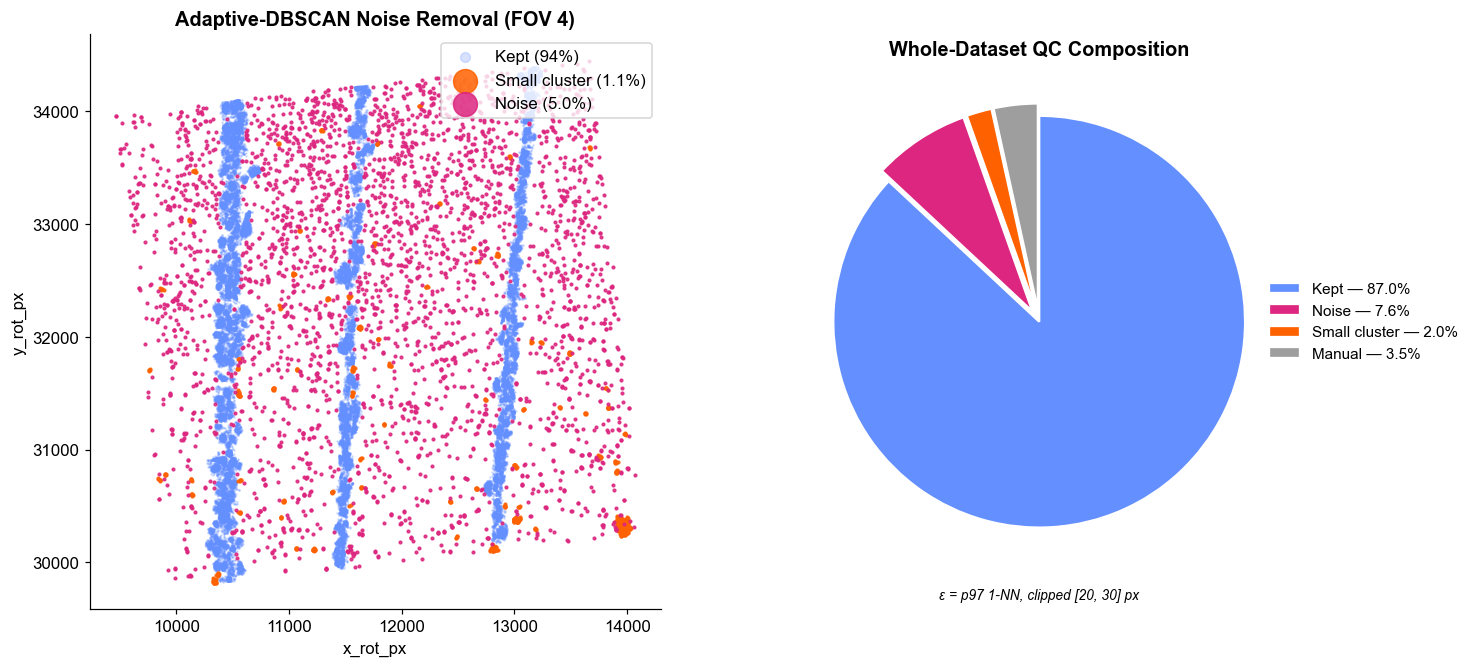

In [5]:
fig, (axA, axB) = plt.subplots(1, 2, figsize=(15, 6.2),
                               gridspec_kw={"width_ratios": [2, 1]})

# Left - representative FOV, kept / small / noise
fv = 4
g = df[df["fov"] == fv]
c = g[["x_rot_px", "y_rot_px"]].to_numpy()
m_keep = (~g["is_noise"] & ~g["is_small_cluster"]).to_numpy()
m_small = g["is_small_cluster"].to_numpy()
m_noise = g["is_noise"].to_numpy()
axA.scatter(c[m_keep, 0], c[m_keep, 1], s=0.5, alpha=0.25, c=C_KEEP,
            rasterized=True, label=f"Kept ({100*m_keep.mean():.0f}%)")
axA.scatter(c[m_small, 0], c[m_small, 1], s=3, alpha=0.85, c=C_SMALL,
            rasterized=True, label=f"Small cluster ({100*m_small.mean():.1f}%)")
axA.scatter(c[m_noise, 0], c[m_noise, 1], s=3, alpha=0.85, c=C_NOISE,
            rasterized=True, label=f"Noise ({100*m_noise.mean():.1f}%)")
axA.set_aspect("equal")
axA.set_xlabel("x_rot_px"); axA.set_ylabel("y_rot_px")
axA.set_title(f"Adaptive-DBSCAN Noise Removal (FOV {fv})")
axA.legend(markerscale=9, loc="upper right")

# Right - whole-dataset QC composition as a pie (mutually exclusive categories)
noise = df["is_noise"]
small = df["is_small_cluster"] & ~df["is_noise"]
manual = df["manually_excluded"] & ~df["is_noise"] & ~df["is_small_cluster"]
kept = ~(noise | small | manual)
sizes = [100 * kept.mean(), 100 * noise.mean(), 100 * small.mean(), 100 * manual.mean()]
labels = ["Kept", "Noise", "Small cluster", "Manual"]
colors = [C_KEEP, C_NOISE, C_SMALL, "#9E9E9E"]
explode = [0.0, 0.06, 0.06, 0.06]
wedges, _ = axB.pie(sizes, colors=colors, explode=explode, startangle=90,
                    counterclock=False,
                    wedgeprops={"edgecolor": "white", "linewidth": 1.5})
axB.legend(wedges, [f"{l} - {s:.1f}%" for l, s in zip(labels, sizes)],
           loc="center left", bbox_to_anchor=(0.92, 0.5), fontsize=10,
           frameon=False)
axB.set_title("Whole-Dataset QC Composition")
axB.text(0, -1.35, "ε = p97 1-NN, clipped [20, 30] px", ha="center",
         fontsize=9, style="italic")

fig.tight_layout()
fig.savefig(FIGS / "14_M3_dbscan_qc.png", dpi=300, bbox_inches="tight")
plt.show()

## M4: Observation-window iterations

The observation window sets the intensity normalisation and edge correction for
Ripley's K, and is the **dominant lever for inferential power** under this
method. We iterated from a rectangular bounding box → convex hull → concave
hull (ratio 0.1), which tracks the true tissue extent of these thin curved
strips far more tightly (areas annotated in Mpx²).

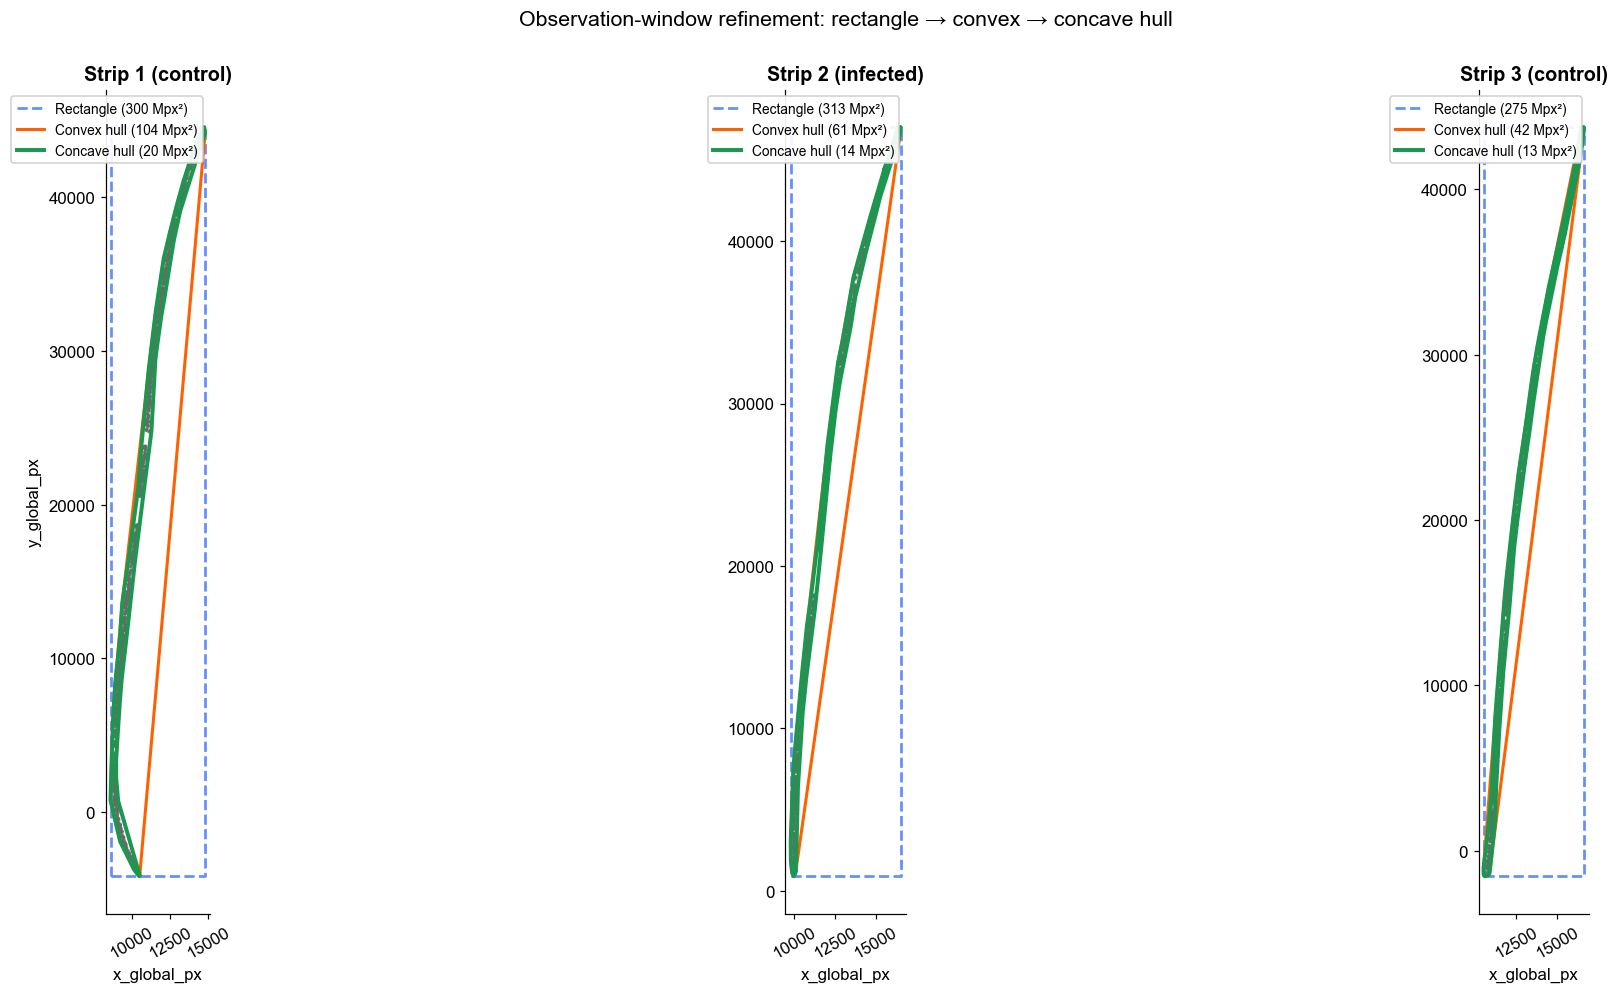

In [6]:
from matplotlib.ticker import MaxNLocator
STRIPS = ["strip_1", "strip_2", "strip_3"]
rng = np.random.default_rng(0)
fig, axes = plt.subplots(1, 3, figsize=(22, 9))

for ax, s in zip(axes, STRIPS):
    sdf = df[clean & (df["strip"] == s)]
    coords = sdf[["x_global_px", "y_global_px"]].to_numpy()
    idx = rng.choice(len(coords), min(8000, len(coords)), replace=False)
    ax.scatter(coords[idx, 0], coords[idx, 1], s=1, alpha=0.18,
               c="dimgrey", rasterized=True)

    xmin, xmax = coords[:, 0].min(), coords[:, 0].max()
    ymin, ymax = coords[:, 1].min(), coords[:, 1].max()
    rect_area = (xmax - xmin) * (ymax - ymin)
    ax.plot([xmin, xmax, xmax, xmin, xmin], [ymin, ymin, ymax, ymax, ymin],
            ls="--", c=C_RECT, lw=1.8, label=f"Rectangle ({rect_area/1e6:.0f} Mpx²)")

    cv = get_convex_hull(sdf)
    cx, cy = cv.exterior.xy
    ax.plot(cx, cy, c=C_CONVEX, lw=2.0, label=f"Convex hull ({cv.area/1e6:.0f} Mpx²)")

    cc = get_concave_hull(sdf, concave_ratio=0.1)
    px, py = cc.exterior.xy
    ax.plot(px, py, c=C_CONCAVE, lw=2.6, label=f"Concave hull ({cc.area/1e6:.0f} Mpx²)")

    # Equal aspect keeps the true tissue geometry undistorted (the thin curved
    # strips really are ~1:12). The quantitative shrinkage is in the legend areas.
    ax.set_aspect("equal")
    ax.xaxis.set_major_locator(MaxNLocator(3))
    ax.tick_params(axis="x", labelrotation=30)
    ax.set_xlabel("x_global_px")
    ax.set_title(STRIP_LABELS[s])
    ax.legend(fontsize=9, loc="upper right", framealpha=0.92)

axes[0].set_ylabel("y_global_px")
fig.suptitle("Observation-window refinement: rectangle → convex → concave hull",
             fontsize=14, y=1.0)
fig.tight_layout()
fig.savefig(FIGS / "14_M4_window_iterations.png", dpi=300, bbox_inches="tight")
plt.show()

## M5: Multi-scale r-value design + edge correction

`r` is sampled on a two-segment grid: dense in the cell–cell signalling range
([5, 50] px, 30 points) and coarse for tissue-scale context ((50, 250] px, 20
points). Centre: the four reference radii drawn on a real KRT8 transcript set
the physical scale. Right: a boundary transcript's search disc is clipped by
the hull, and each point is reweighted by the fraction of its disc inside the
window (Shapely edge correction).

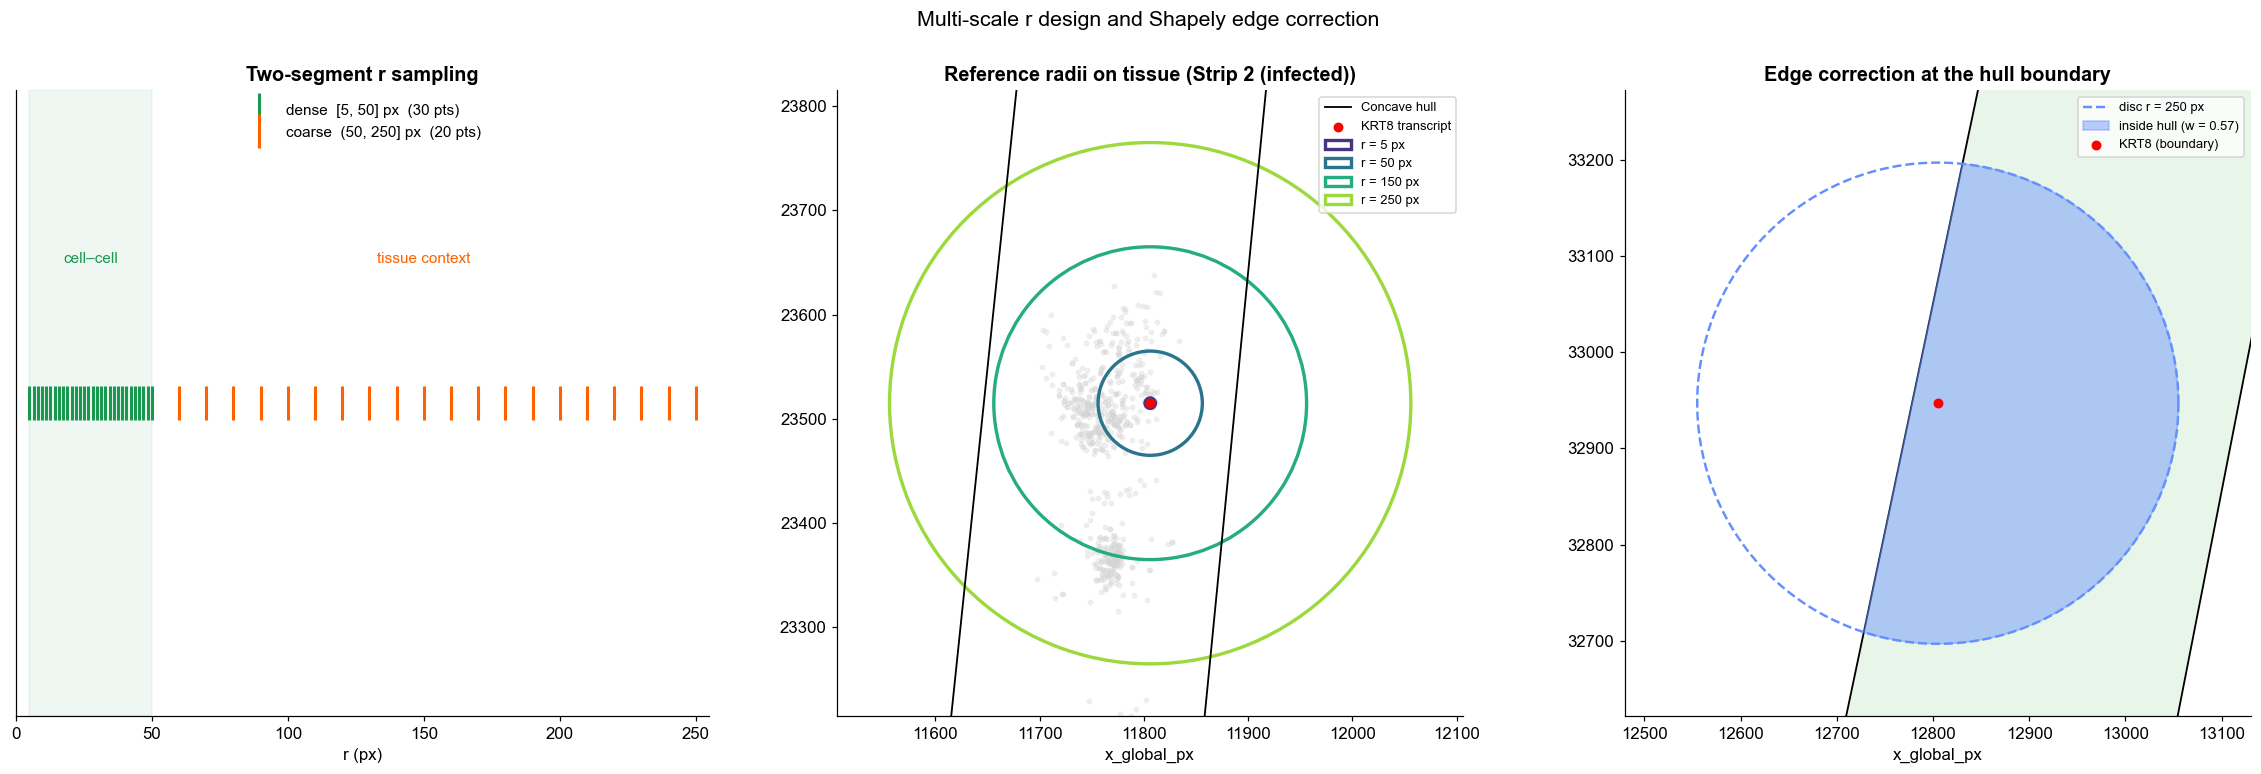

In [7]:
from matplotlib.patches import Circle
from shapely.geometry import Point as ShPoint

R_MIN, R_CC, R_MAX, N_CC, N_COARSE = 5, 50, 250, 30, 20
r_cc = np.linspace(R_MIN, R_CC, N_CC)
r_coarse = np.linspace(R_CC, R_MAX, N_COARSE + 1)[1:]
r_vals = np.concatenate([r_cc, r_coarse])
RADII_SHOW = np.array([R_MIN, R_CC, (R_CC + R_MAX) // 2, R_MAX])
cols = plt.cm.viridis(np.linspace(0.15, 0.85, len(RADII_SHOW)))

VIS_STRIP, VIS_GENE = "strip_2", "KRT8"
sdf = df[clean & (df["strip"] == VIS_STRIP)]
hull = get_concave_hull(sdf, concave_ratio=0.1)
coords = get_coords(sdf, VIS_GENE)

cen = hull.centroid
p_in = coords[np.argmin(np.hypot(coords[:, 0] - cen.x, coords[:, 1] - cen.y))]
boundary = hull.boundary
p_edge = coords[np.argmin([boundary.distance(ShPoint(*p)) for p in coords])]
hx, hy = hull.exterior.xy

fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=(21, 7))

# (1) two-segment r-spacing schematic
a1.plot(r_cc, np.zeros_like(r_cc), "|", ms=22, c="#1A9850", mew=2,
        label=f"dense  [{R_MIN}, {R_CC}] px  ({N_CC} pts)")
a1.plot(r_coarse, np.zeros_like(r_coarse), "|", ms=22, c="#FE6100", mew=2,
        label=f"coarse  ({R_CC}, {R_MAX}] px  ({N_COARSE} pts)")
a1.axvspan(R_MIN, R_CC, color="#1A9850", alpha=0.07)
a1.set_xlim(0, R_MAX + 5); a1.set_ylim(-1, 1); a1.set_yticks([])
a1.set_xlabel("r (px)")
a1.set_title("Two-segment r sampling")
a1.legend(loc="upper center", fontsize=10, frameon=False)
a1.text((R_MIN + R_CC) / 2, 0.45, "cell–cell", ha="center", color="#1A9850", fontsize=10)
a1.text((R_CC + R_MAX) / 2, 0.45, "tissue context", ha="center", color="#FE6100", fontsize=10)

# (2) radii scale on a real transcript
a2.scatter(sdf["x_global_px"], sdf["y_global_px"], s=8, alpha=0.3,
           c="lightgrey", rasterized=True)
a2.plot(hx, hy, "k-", lw=1.2, label="Concave hull")
a2.scatter(*p_in, s=30, c="red", zorder=5, label=f"{VIS_GENE} transcript")
for r, col in zip(RADII_SHOW, cols):
    a2.add_patch(Circle(p_in, r, fill=False, ec=col, lw=2.2, label=f"r = {r:.0f} px"))
pad = R_MAX * 1.2
a2.set_xlim(p_in[0] - pad, p_in[0] + pad); a2.set_ylim(p_in[1] - pad, p_in[1] + pad)
a2.set_aspect("equal"); a2.set_xlabel("x_global_px")
a2.set_title(f"Reference radii on tissue ({STRIP_LABELS[VIS_STRIP]})")
a2.legend(fontsize=8.5, loc="upper right")

# (3) edge correction at a boundary transcript
w = fraction_inside_hull(tuple(p_edge), R_MAX, hull)
disc = ShPoint(*p_edge).buffer(R_MAX, resolution=64)
inter = hull.intersection(disc)
a3.fill(hx, hy, color="#E8F5E9", ec="k", lw=1.2, zorder=0)
dx, dy = disc.exterior.xy
a3.plot(dx, dy, c="#648FFF", lw=1.6, ls="--", label=f"disc r = {R_MAX} px")
if not inter.is_empty:
    ix, iy = inter.exterior.xy
    a3.fill(ix, iy, color="#648FFF", alpha=0.45, label=f"inside hull (w = {w:.2f})")
a3.scatter(*p_edge, s=30, c="red", zorder=5, label=f"{VIS_GENE} (boundary)")
pad2 = R_MAX * 1.3
a3.set_xlim(p_edge[0] - pad2, p_edge[0] + pad2); a3.set_ylim(p_edge[1] - pad2, p_edge[1] + pad2)
a3.set_aspect("equal"); a3.set_xlabel("x_global_px")
a3.set_title("Edge correction at the hull boundary")
a3.legend(fontsize=8.5, loc="upper right")

fig.suptitle("Multi-scale r design and Shapely edge correction", fontsize=14, y=1.0)
fig.tight_layout()
fig.savefig(FIGS / "14_M5_rscale.png", dpi=300, bbox_inches="tight")
plt.show()

## T: Tool-capability matrix

Where STIPPLE sits among published tools. Four capabilities define the niche:
**segmentation-free** operation, working on **raw transcripts**, answering the
**ligand–receptor co-localisation** question, and using **point-pattern
statistics**. STIPPLE is the only tool that satisfies all four. Facts verified
2026-06-01 against primary sources (`memory/project_competitor_landscape.md`):
Bento, Squidpy, CellChat/LIANA and Baysor all require a segmentation or
cell-typing step; FICTURE is segmentation-free but answers a different question
(tissue domains); spatstat is a generic point-pattern library, not
ST- or L–R-specific.

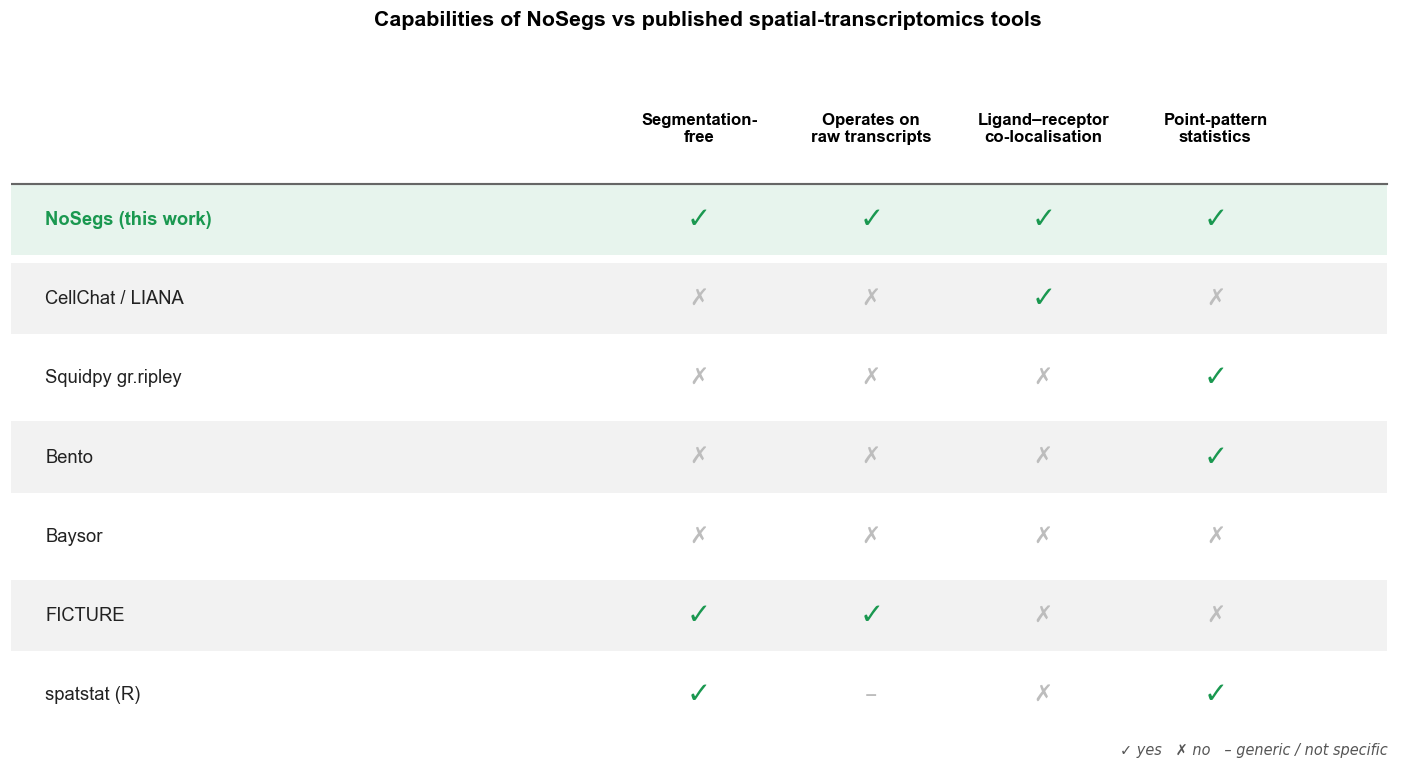

In [8]:
from matplotlib.patches import Rectangle

# Arial lacks the ✓/✗ glyphs, so render the marks in DejaVu Sans (which has them)
# while every label/title stays in the pinned Arial.
MARK_FONT = "DejaVu Sans"

# Capability matrix.  1 = yes, 0 = no, 0.5 = partial / not specific
cols = ["Segmentation-\nfree", "Operates on\nraw transcripts",
        "Ligand–receptor\nco-localisation", "Point-pattern\nstatistics"]
rows = [
    ("STIPPLE (this work)", [1, 1, 1, 1]),
    ("CellChat / LIANA",    [0, 0, 1, 0]),
    ("Squidpy gr.ripley",   [0, 0, 0, 1]),
    ("Bento",               [0, 0, 0, 1]),
    ("Baysor",              [0, 0, 0, 0]),
    ("FICTURE",             [1, 1, 0, 0]),
    ("spatstat (R)",        [1, 0.5, 0, 1]),
]

GREEN, RED, GREY = "#1A9850", "#D73027", "#BDBDBD"
nrow, ncol = len(rows), len(cols)
LABEL_W = 3.2
col_x = [LABEL_W + 0.6 + j for j in range(ncol)]

fig, ax = plt.subplots(figsize=(13, 7.2))
ax.set_xlim(-0.2, LABEL_W + ncol + 0.7)
ax.set_ylim(-0.9, nrow + 1.1)
ax.axis("off")

# Column headers
for j, cname in enumerate(cols):
    ax.text(col_x[j], nrow + 0.15, cname, ha="center", va="center",
            fontsize=11, fontweight="bold")
ax.plot([-0.2, LABEL_W + ncol + 0.6], [nrow - 0.55, nrow - 0.55],
        color="#666666", lw=1.4)

for i, (rname, marks) in enumerate(rows):
    y = nrow - 1 - i
    us = (i == 0)
    if us:
        ax.add_patch(Rectangle((-0.2, y - 0.45), LABEL_W + ncol + 0.8, 0.9,
                               facecolor=GREEN, alpha=0.10, zorder=0))
    elif i % 2 == 1:
        ax.add_patch(Rectangle((-0.2, y - 0.45), LABEL_W + ncol + 0.8, 0.9,
                               facecolor="#F2F2F2", zorder=0))
    ax.text(0.0, y, rname, ha="left", va="center",
            fontsize=12, fontweight="bold" if us else "normal",
            color=GREEN if us else "#222222")
    for j, v in enumerate(marks):
        if v == 1:
            ax.text(col_x[j], y, "✓", ha="center", va="center", family=MARK_FONT,
                    fontsize=19, color=GREEN, fontweight="bold")
        elif v == 0:
            ax.text(col_x[j], y, "✗", ha="center", va="center", family=MARK_FONT,
                    fontsize=15, color=GREY)
        else:
            ax.text(col_x[j], y, "–", ha="center", va="center", family=MARK_FONT,
                    fontsize=16, color=GREY)

ax.set_title("Capabilities of STIPPLE vs published spatial-transcriptomics tools",
             fontsize=14, fontweight="bold", pad=18)
ax.text(LABEL_W + ncol + 0.6, -0.7,
        "✓ yes   ✗ no   – generic / not specific", family=MARK_FONT,
        ha="right", va="center", fontsize=9.5, color="#555555", style="italic")

fig.tight_layout()
fig.savefig(FIGS / "14_T_tool_positioning.png", dpi=300, bbox_inches="tight")
plt.show()

## M6: Workflow flowchart + quick-start

The whole STIPPLE pipeline at a glance, with the tunable choices at each step
(amber) and a quick-start guide to when the tool applies.

saved 14_M6_workflow.png


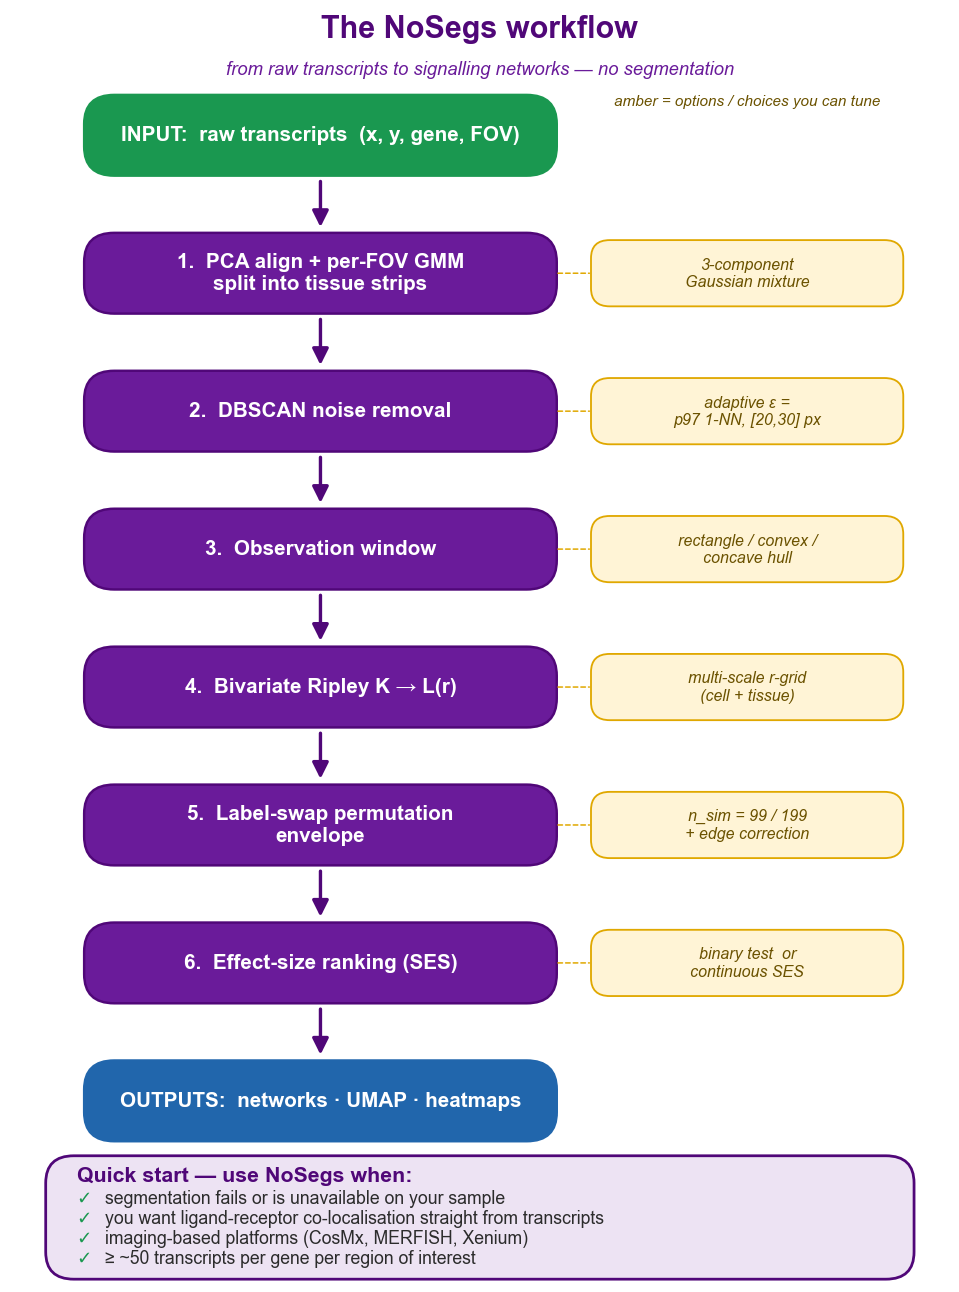

In [9]:
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

PURPLE = "#500778"; PURPLE_L = "#EDE3F3"; STAGE = "#6A1B9A"
OPT_BG = "#FFF4D6"; OPT_ED = "#E0A800"; IN_BG = "#1A9850"; OUT_BG = "#2166AC"; TXT = "#2C2C2C"

fig, ax = plt.subplots(figsize=(11, 15))
ax.set_xlim(0, 100); ax.set_ylim(0, 140); ax.axis("off")

def box(x, y, w, h, text, fc, ec, tc="white", fs=13.5, rad=0.08):
    p = FancyBboxPatch((x, y), w, h, boxstyle=f"round,pad=0.2,rounding_size={rad*40}",
                       linewidth=1.6, edgecolor=ec, facecolor=fc, mutation_aspect=1)
    ax.add_patch(p)
    ax.text(x + w/2, y + h/2, text, ha="center", va="center", color=tc,
            fontsize=fs, fontweight="bold")

def opt(x, y, w, h, text):
    p = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.15,rounding_size=2",
                       linewidth=1.2, edgecolor=OPT_ED, facecolor=OPT_BG)
    ax.add_patch(p)
    ax.text(x + w/2, y + h/2, text, ha="center", va="center", color="#6B5200",
            fontsize=10.5, fontstyle="italic")

def arrow(y0, y1, x=33):
    ax.add_patch(FancyArrowPatch((x, y0), (x, y1), arrowstyle="-|>",
                 mutation_scale=22, linewidth=2.2, color=PURPLE))

ax.text(50, 137, "The STIPPLE workflow", ha="center", fontsize=20, fontweight="bold", color=PURPLE)
ax.text(50, 133, "from raw transcripts to signalling networks - no segmentation",
        ha="center", fontsize=12, fontstyle="italic", color="#6A1B9A")
ax.text(78.5, 129.5, "amber = options / choices you can tune",
        ha="center", fontsize=10, fontstyle="italic", color="#6B5200")

bx, bw, bh = 8, 50, 8.5
ox, ow, oh = 62, 33, 7.0
stages = [
    ("INPUT:  raw transcripts  (x, y, gene, FOV)", IN_BG, IN_BG, None),
    ("1.  PCA align + per-FOV GMM\nsplit into tissue strips", STAGE, PURPLE, "3-component\nGaussian mixture"),
    ("2.  DBSCAN noise removal", STAGE, PURPLE, "adaptive ε =\np97 1-NN, [20,30] px"),
    ("3.  Observation window", STAGE, PURPLE, "rectangle / convex /\nconcave hull"),
    ("4.  Bivariate Ripley K → L(r)", STAGE, PURPLE, "multi-scale r-grid\n(cell + tissue)"),
    ("5.  Label-swap permutation\nenvelope", STAGE, PURPLE, "n_sim = 99 / 199\n+ edge correction"),
    ("6.  Effect-size ranking (SES)", STAGE, PURPLE, "binary test  or\ncontinuous SES"),
    ("OUTPUTS:  networks · UMAP · heatmaps", OUT_BG, OUT_BG, None),
]
y = 122; gap = 15.2
for i, (label, fc, ec, option) in enumerate(stages):
    box(bx, y, bw, bh, label, fc, ec)
    if option:
        opt(ox, y + (bh-oh)/2, ow, oh, option)
        ax.add_patch(FancyArrowPatch((bx+bw, y+bh/2), (ox, y+oh/2+(bh-oh)/2),
                     arrowstyle="-", linewidth=1.0, color=OPT_ED, linestyle=(0,(3,2))))
    if i < len(stages) - 1:
        arrow(y - 0.5, y - gap + bh + 0.5, x=bx + bw/2)
    y -= gap

qx, qy, qw, qh = 4, 0.5, 92, 13.0
p = FancyBboxPatch((qx, qy), qw, qh, boxstyle="round,pad=0.3,rounding_size=3",
                   linewidth=1.8, edgecolor=PURPLE, facecolor=PURPLE_L)
ax.add_patch(p)
ax.text(qx + 3, qy + qh - 1.9, "Quick start - use STIPPLE when:", fontsize=14,
        fontweight="bold", color=PURPLE, va="center")
uses = [
    "segmentation fails or is unavailable on your sample",
    "you want ligand-receptor co-localisation straight from transcripts",
    "imaging-based platforms (CosMx, MERFISH, Xenium)",
    "≥ ~50 transcripts per gene per region of interest",
]
for j, u in enumerate(uses):
    cy = qy + qh - 4.4 - 2.2 * j
    ax.text(qx + 3, cy, "✓", fontsize=12, color=IN_BG, va="center",
            fontweight="bold", fontfamily="DejaVu Sans")
    ax.text(qx + 6, cy, u, fontsize=11.5, color=TXT, va="center")

fig.savefig(FIGS / "14_M6_workflow.png", dpi=300, bbox_inches="tight")
print("saved 14_M6_workflow.png")
plt.show()
